# Freight Rate Prediction Challenge

This notebook documents the reproducible Spotter freight-rate regression solution. The labeled development data covers January through October 2025, while the final prediction period covers November and December 2025. Model selection uses a time-based holdout to simulate future prediction. The implementation is in `src/pipeline.py`.

## 1. Objective and data contract

The target is `posted_rate` in `data/train-test.csv`. The final deliverable is `validation_predictions.csv` with exactly `load_id,predicted_rate` for 12,000 validation loads. The fixed December scenario file contains 31 rows and is used by the supplied scorer to create the required chart. The scorer validates output structure and does not calculate the hidden accuracy metric.

In [4]:
from pathlib import Path
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
ROOT = Path.cwd()
if not (ROOT / "src" / "pipeline.py").exists():
    ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from src.pipeline import run_experiments, train_final_and_predict

In [7]:
DATA = ROOT / "data"
train_raw = pd.read_csv(DATA / "train-test.csv")
validation_raw = pd.read_csv(DATA / "validation.csv")
template = pd.read_csv(DATA / "validation-predictions-template.csv")
december_raw = pd.read_csv(DATA / "december-chart-inputs.csv")
for frame in [train_raw, validation_raw, december_raw]:
    frame["date"] = pd.to_datetime(frame["date"])

In [8]:

print("Development:", train_raw.shape, train_raw.date.min().date(), "to", train_raw.date.max().date())
print("Final validation:", validation_raw.shape, validation_raw.date.min().date(), "to", validation_raw.date.max().date())
print("December inputs:", december_raw.shape)
print("Development missing values:\n", train_raw.isna().sum()[train_raw.isna().sum() > 0])
print("Negative weights: train =", int((train_raw.weight < 0).sum()), ", validation =", int((validation_raw.weight < 0).sum()))

Development: (48000, 14) 2025-01-01 to 2025-10-31
Final validation: (12000, 13) 2025-11-01 to 2025-12-31
December inputs: (31, 7)
Development missing values:
 weight          300
market_index    374
dtype: int64
Negative weights: train = 292 , validation = 145


## 2. Exploratory findings and data quality

The development target is right-skewed. Distance has a strong raw relationship with `posted_rate`, and average rates differ by equipment. Validation includes eight pickup cities and eight delivery cities not seen during development, plus 736 unseen routes. Missing and negative weights are retained and represented with explicit quality features rather than being silently deleted.

In [11]:
routes_train = set(zip(train_raw.pickup, train_raw.delivery))
routes_validation = set(zip(validation_raw.pickup, validation_raw.delivery))
print("Unseen pickup cities:", sorted(set(validation_raw.pickup) - set(train_raw.pickup)))
print("Unseen delivery cities:", sorted(set(validation_raw.delivery) - set(train_raw.delivery)))
print("Unseen validation routes:", len(routes_validation - routes_train))


Unseen pickup cities: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
Unseen delivery cities: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
Unseen validation routes: 736


In [12]:
print("Target summary:\n", train_raw.posted_rate.describe().round(2))
print("Distance correlation:", round(train_raw[["posted_rate", "distance"]].corr().iloc[0, 1], 3))

Target summary:
 count    48000.00
mean      2373.98
std       1486.49
min         57.22
25%       1251.55
50%       2030.76
75%       3330.75
max      25533.00
Name: posted_rate, dtype: float64
Distance correlation: 0.909


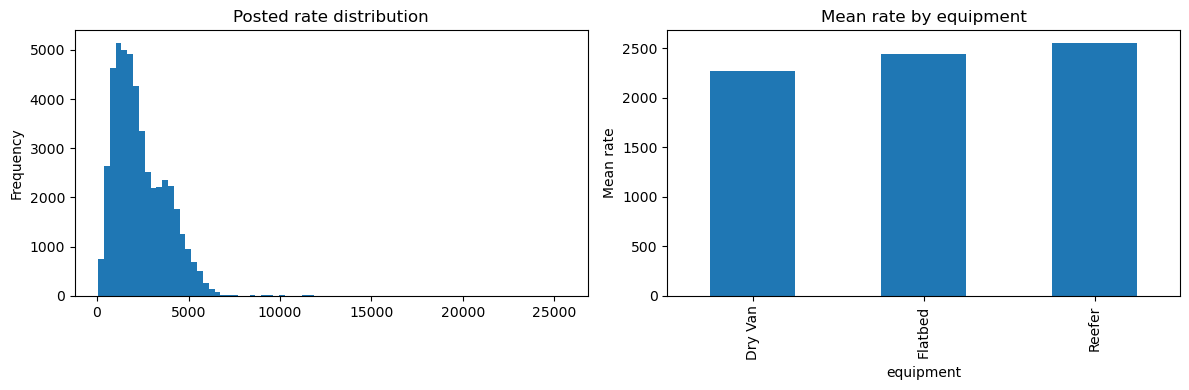

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_raw.posted_rate.plot.hist(bins=80, ax=axes[0], title="Posted rate distribution")
train_raw.groupby("equipment").posted_rate.mean().sort_values().plot.bar(ax=axes[1], title="Mean rate by equipment", ylabel="Mean rate")
plt.tight_layout()
plt.show()

## 3. Time-based validation and experiments

The primary holdout uses January 1 through August 31, 2025 for development and September 1 through October 31, 2025 for evaluation. This reflects the future-dated final validation period. The experiment compares a median baseline, Ridge with one-hot categorical variables, and CatBoost with native categorical handling.

In [13]:
model_results, split_details = run_experiments(train_raw)
print(json.dumps(split_details, indent=2))
model_results

{
  "split": {
    "development_start": "2025-01-01",
    "development_end": "2025-08-31",
    "holdout_start": "2025-09-01",
    "holdout_end": "2025-10-31",
    "development_rows": 38477,
    "holdout_rows": 9523
  },
  "catboost_model": {
    "iterations": 700,
    "depth": 8,
    "learning_rate": 0.06,
    "random_seed": 42
  }
}


,model,MAE,RMSE,seconds
0,Median baseline,1148.923726,1569.424179,NaN
1,Ridge,148.426421,642.321093,0.56
2,CatBoost,144.840823,651.984001,39.83


## 4. Final training and outputs

CatBoost is selected because the data combines nonlinear distance effects, categorical routes, unseen categories, and missing values. The final model is retrained on all 48,000 labeled rows. December fields absent from the input file use coordinate mappings and numeric medians derived from development data only.

In [4]:
validation_output, december_output = train_final_and_predict(train_raw, validation_raw, december_raw)
if not template["load_id"].equals(validation_output["load_id"]):
    raise ValueError("Template IDs do not match validation IDs")
template["predicted_rate"] = validation_output["predicted_rate"].to_numpy()
template.to_csv(ROOT / "validation_predictions.csv", index=False)
december_output.to_csv(DATA / "december-chart-inputs.csv", index=False)
print("Validation output:", template.shape, "missing:", int(template.predicted_rate.isna().sum()))
print("Minimum validation prediction:", template.predicted_rate.min())
print("December output:", december_output.shape, december_output.date.min().date(), "to", december_output.date.max().date())

Validation output: (12000, 2) missing: 0
Minimum validation prediction: 171.20151214583257
December output: (31, 7) 2025-12-01 to 2025-12-31


## 5. Scorer validation and conclusion

The unchanged `score.py` validates the exact 12,000 validation IDs, 31 December dates, fixed December inputs, and positive finite predictions, then creates `scorer_results/candidate_december.png`. Development metrics are MAE and RMSE because the supplied scorer does not expose Spotter's hidden final metric.

In [5]:
chart = ROOT / "scorer_results" / "candidate_december.png"
print("Validation predictions:", (ROOT / "validation_predictions.csv").resolve())
print("December predictions:", (DATA / "december-chart-inputs.csv").resolve())
print("Chart exists:", chart.exists(), chart.resolve())
print(model_results.to_string(index=False))

Validation predictions: C:\Users\njnay\Desktop\ML enginner\validation_predictions.csv
December predictions: C:\Users\njnay\Desktop\ML enginner\data\december-chart-inputs.csv
Chart exists: True C:\Users\njnay\Desktop\ML enginner\scorer_results\candidate_december.png
          model         MAE        RMSE  seconds
Median baseline 1148.923726 1569.424179      NaN
          Ridge  148.426421  642.321093     0.43
       CatBoost  144.840823  651.984001    39.60
